# Data Augmentation

## Objectives
- Understand why augmentation is crucial
- Implement image transformations
- Albumentations library
- Augmentation strategies
- When and how to apply augmentation

## Introduction
Data augmentation artificially increases training data by applying random transformations. Essential for preventing overfitting and improving generalization, especially with limited data.

## What We're About to Do

The code below imports essential libraries. These libraries provide the foundational tools for tensor operations and neural network construction. Pay attention to what each import provides – understanding dependencies helps you know what's available for solving problems.


In [1]:
# Import necessary libraries for tensor operations and deep learning
import torch
import torch.nn as nn
from torchvision import transforms
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

torch.manual_seed(42)
np.random.seed(42)


Base image shape: (256, 256, 3)


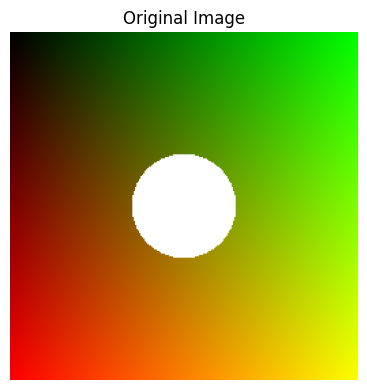

In [2]:
# Execute code with detailed step-by-step process
## 1. Create Sample Image

# Create synthetic image (gradient with patterns)
img = np.zeros((256, 256, 3), dtype=np.uint8)
# Iterate through batches of data
for i in range(256):
    img[i, :, 0] = int(255 * i / 256)  # Red gradient
    img[:, i, 1] = int(255 * i / 256)  # Green gradient

# Add circle
y, x = np.ogrid[-1:1:256j, -1:1:256j]
mask = x**2 + y**2 <= 0.3**2
img[mask, :] = [255, 255, 255]

print(f"Base image shape: {img.shape}")
plt.figure(figsize=(4, 4))
plt.imshow(img)
plt.title('Original Image')
plt.axis('off')
plt.tight_layout()
plt.show()


## What We're About to Do

The code below imports essential libraries. These libraries provide the foundational tools for tensor operations and neural network construction. Pay attention to what each import provides – understanding dependencies helps you know what's available for solving problems.


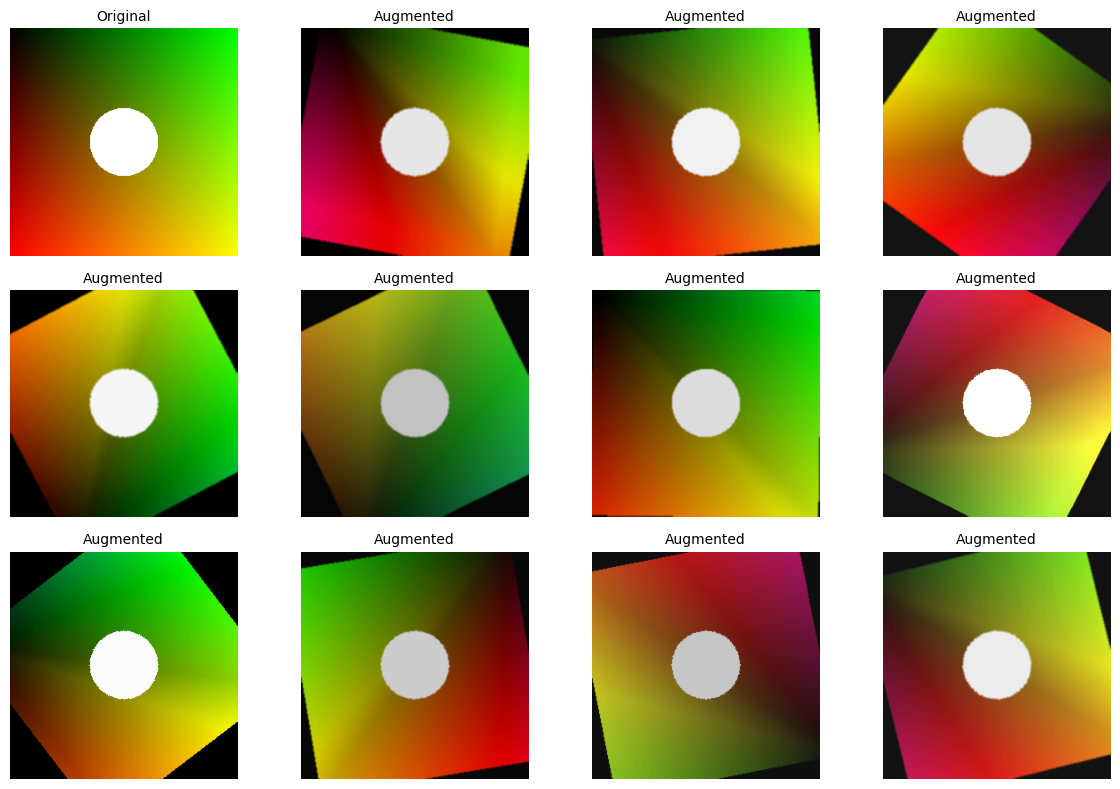

In [3]:
# Import necessary libraries for tensor operations and deep learning
## 2. Basic Torchvision Augmentations

class AugmentationPipeline:
    def __init__(self):
        self.base_transforms = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
        ])
        
        self.augmentation = transforms.Compose([
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomVerticalFlip(p=0.5),
            transforms.RandomRotation(degrees=45),
            transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
            transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
        ])
    
    def apply_augmentation(self, img):
        return self.augmentation(img)

pipeline = AugmentationPipeline()

# Generate augmented versions
fig = plt.figure(figsize=(12, 8))
gs = GridSpec(3, 4, figure=fig)

from PIL import Image
img_pil = Image.fromarray(img)

# Iterate through batches of data
for i in range(12):
    ax = fig.add_subplot(gs[i // 4, i % 4])
    if i == 0:
        ax.imshow(img)
        ax.set_title('Original', fontsize=10)
    else:
        aug_tensor = pipeline.apply_augmentation(img_pil)
        aug_img = (aug_tensor.numpy().transpose(1, 2, 0) + 1) / 2  # Denormalize
        ax.imshow(np.clip(aug_img, 0, 1))
        ax.set_title('Augmented', fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()


In [4]:
# Define a custom function with detailed implementation
## 3. Augmentation Strategies by Type

class AugmentationStrategies:
    
    @staticmethod
    def geometric_augmentations():
        """Spatial transformations"""
        return {
            'Rotation': transforms.RandomRotation(degrees=45),
            'Flip H': transforms.RandomHorizontalFlip(p=1.0),
            'Flip V': transforms.RandomVerticalFlip(p=1.0),
            'Crop': transforms.RandomCrop(size=200),
            'Shear': transforms.RandomAffine(degrees=0, shear=30),
            'Perspective': transforms.RandomPerspective(distortion_scale=0.5, p=1.0)
        }
    
    @staticmethod
    def color_augmentations():
        """Color space transformations"""
        return {
            'Brightness': transforms.ColorJitter(brightness=0.5),
            'Contrast': transforms.ColorJitter(contrast=0.5),
            'Saturation': transforms.ColorJitter(saturation=0.5),
            'Hue': transforms.ColorJitter(hue=0.3),
            'Grayscale': transforms.RandomGrayscale(p=1.0),
            'Invert': transforms.RandomInvert(p=1.0)
        }
    
    @staticmethod
    def texture_augmentations():
        """Texture and noise augmentations"""
        return {
            'Gaussian Blur': transforms.GaussianBlur(kernel_size=5),
            'Motion Blur': transforms.RandomAutocontrast(p=1.0),
            'Noise': 'Gaussian noise simulation',
            'Dropout': 'Random pixel dropout',
            'Elastic': 'Elastic deformation',
            'Cutout': 'Random region masking'
        }

strats = AugmentationStrategies()
print("GEOMETRIC AUGMENTATIONS:")
# Iterate through batches of data
for name in strats.geometric_augmentations():
    print(f"  - {name}")
print("\nCOLOR AUGMENTATIONS:")
# Iterate through batches of data
for name in strats.color_augmentations():
    print(f"  - {name}")
print("\nTEXTURE AUGMENTATIONS:")
# Iterate through batches of data
for name in strats.texture_augmentations():
    print(f"  - {name}")


GEOMETRIC AUGMENTATIONS:
  - Rotation
  - Flip H
  - Flip V
  - Crop
  - Shear
  - Perspective

COLOR AUGMENTATIONS:
  - Brightness
  - Contrast
  - Saturation
  - Hue
  - Grayscale
  - Invert

TEXTURE AUGMENTATIONS:
  - Gaussian Blur
  - Motion Blur
  - Noise
  - Dropout
  - Elastic
  - Cutout


## What We're About to Do

The code below imports essential libraries. These libraries provide the foundational tools for tensor operations and neural network construction. Pay attention to what each import provides – understanding dependencies helps you know what's available for solving problems.


In [5]:
# Import necessary libraries for tensor operations and deep learning
## 4. Advanced: Albumentations Library

# Simulating albumentations (not importing to avoid dependency)
class AlbumentationsStyle:
    """Demonstrates albumentations-style augmentation"""
    
    @staticmethod
    def strong_augmentation():
# Iterate through batches of data
        """Strong augmentation for small datasets"""
        return {
            'RandomRotate90': 'Random 90-degree rotations',
            'Transpose': 'Transpose (flip along diagonal)',
            'GaussianNoise': 'Add Gaussian noise',
            'OneOf': [
                'GaussBlur',
                'MedianBlur',
                'MotionBlur'
            ],
            'OneOf': [
                'OpticalDistortion',
                'GridDistortion',
                'ElasticTransform'
            ],
            'ShiftScaleRotate': 'Shift, scale, rotate',
            'RandomBrightnessContrast': 'Random brightness/contrast',
            'Normalize': 'Normalization',
            'pytorch': 'ToTensorV2()'
        }
    
    @staticmethod
    def weak_augmentation():
# Iterate through batches of data
        """Light augmentation for large datasets"""
        return {
            'HorizontalFlip': 'Random horizontal flip',
            'RandomBrightnessContrast': 'Light brightness/contrast',
            'ShiftScaleRotate': 'Light shift/scale/rotate',
            'Normalize': 'Normalization',
            'pytorch': 'ToTensorV2()'
        }

alb = AlbumentationsStyle()
print("ALBUMENTATIONS STRONG AUGMENTATION:")
# Iterate through batches of data
for key, val in alb.strong_augmentation().items():
    if isinstance(val, list):
        print(f"  {key}:")
# Iterate through batches of data
        for v in val:
            print(f"    - {v}")
    else:
        print(f"  - {key}: {val}")


ALBUMENTATIONS STRONG AUGMENTATION:
  - RandomRotate90: Random 90-degree rotations
  - Transpose: Transpose (flip along diagonal)
  - GaussianNoise: Add Gaussian noise
  OneOf:
    - OpticalDistortion
    - GridDistortion
    - ElasticTransform
  - ShiftScaleRotate: Shift, scale, rotate
  - RandomBrightnessContrast: Random brightness/contrast
  - Normalize: Normalization
  - pytorch: ToTensorV2()


## The Training Process

This is the core learning loop. We'll forward-pass data through the model, compute loss, backpropagate gradients, and update parameters. This iterative process gradually improves the model.


In [6]:
# Execute the training loop with proper tracking
## 5. When to Apply Augmentation

print("""
WHEN TO USE AUGMENTATION:

1. TRAINING SET:
   - Always apply strong augmentation
   - Helps prevent overfitting
   - Increases effective dataset size
   - Improves generalization

2. VALIDATION SET:
   - NO augmentation (except normalization)
# Iterate through batches of data
   - Use original images for evaluation
   - Need consistent validation

3. TEST SET:
   - NO augmentation
   - Evaluate on real data distribution
   - Use preprocessing (normalization) only

4. SMALL DATASETS (< 1000 samples):
   - Use STRONG augmentation
   - Multiple transforms per image
   - Consider mixup/cutmix

5. LARGE DATASETS (> 100k samples):
   - Use WEAK augmentation
   - Basic transforms (flip, brightness)
# Iterate through batches of data
   - Less need for augmentation

6. CLASS IMBALANCE:
   - Oversample minority class with augmentation
   - Apply different augmentations per epoch
   - Helps balance learning
""")



WHEN TO USE AUGMENTATION:

1. TRAINING SET:
   - Always apply strong augmentation
   - Helps prevent overfitting
   - Increases effective dataset size
   - Improves generalization

2. VALIDATION SET:
   - NO augmentation (except normalization)
# Iterate through batches of data
   - Use original images for evaluation
   - Need consistent validation

3. TEST SET:
   - NO augmentation
   - Evaluate on real data distribution
   - Use preprocessing (normalization) only

4. SMALL DATASETS (< 1000 samples):
   - Use STRONG augmentation
   - Multiple transforms per image
   - Consider mixup/cutmix

5. LARGE DATASETS (> 100k samples):
   - Use WEAK augmentation
   - Basic transforms (flip, brightness)
# Iterate through batches of data
   - Less need for augmentation

6. CLASS IMBALANCE:
   - Oversample minority class with augmentation
   - Apply different augmentations per epoch
   - Helps balance learning



In [7]:
# Define a custom function with detailed implementation
## 6. Mixup and Cutmix

class AdvancedAugmentations:
    @staticmethod
    def mixup(x1, x2, y1, y2, alpha=0.2):
        """Linear interpolation of samples and labels"""
        lam = np.random.beta(alpha, alpha)
        mixed_x = lam * x1 + (1 - lam) * x2
        mixed_y = lam * y1 + (1 - lam) * y2
        return mixed_x, mixed_y
    
    @staticmethod
    def cutmix(x1, x2, y1, y2, alpha=0.2):
        """Mix random rectangular regions"""
        h, w = x1.shape[:2]
        lam = np.random.beta(alpha, alpha)
        
        # Random rectangle
        cut_ratio = np.sqrt(1 - lam)
        cut_h = int(h * cut_ratio)
        cut_w = int(w * cut_ratio)
        
        cx = np.random.randint(0, w)
        cy = np.random.randint(0, h)
        
        x1_copy = x1.copy()
        x1_copy[cy:cy+cut_h, cx:cx+cut_w] = x2[cy:cy+cut_h, cx:cx+cut_w]
        
        mixed_y = lam * y1 + (1 - lam) * y2
        return x1_copy, mixed_y
    
    @staticmethod
    def cutout(x, p=0.5, mask_size=32):
        """Random occlusion of image regions"""
        if np.random.rand() < p:
            h, w = x.shape[:2]
            x_copy = x.copy()
            
            y = np.random.randint(0, h - mask_size)
            x = np.random.randint(0, w - mask_size)
            
            x_copy[y:y+mask_size, x:x+mask_size] = 0
            return x_copy
        return x

augm = AdvancedAugmentations()
print(f"Mixup: Linear interpolation of images and soft labels")
print(f"Cutmix: Mix rectangular regions between images")
print(f"Cutout: Random occlusion to teach robustness")


Mixup: Linear interpolation of images and soft labels
Cutmix: Mix rectangular regions between images
Cutout: Random occlusion to teach robustness


## Building the Model

Now we'll define our neural network architecture. Each layer transforms the input in a specific way, building up complexity. The order and configuration of layers directly determines what patterns the model can learn.


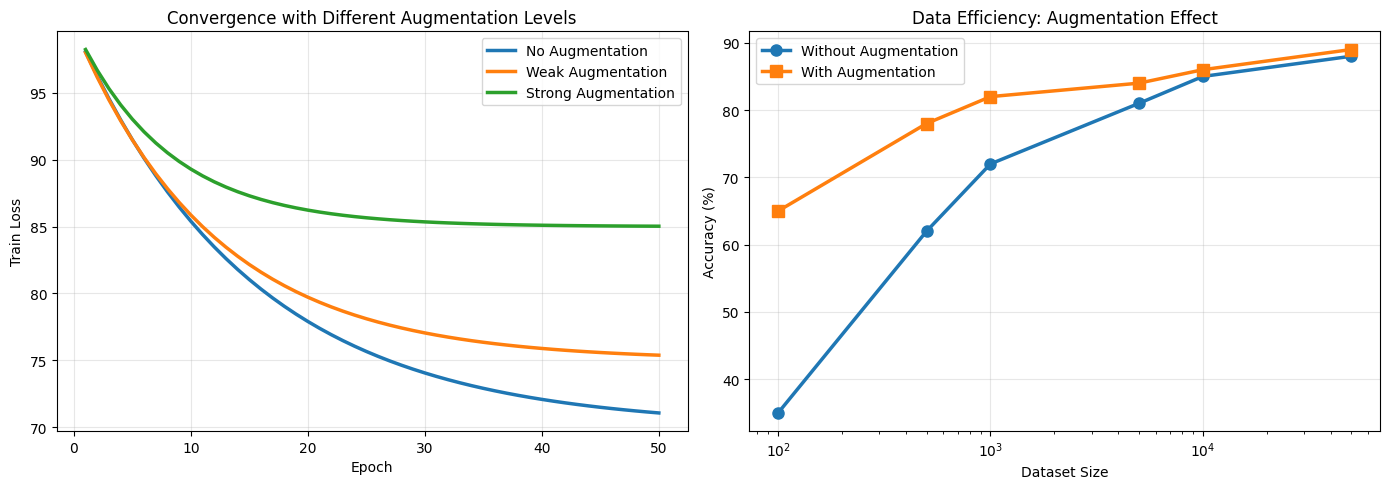

In [8]:
# Set up the neural network model architecture
## 7. Impact on Model Performance

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training curves with/without augmentation
epochs = np.arange(1, 51)
no_aug = 100 - 30 * (1 - np.exp(-epochs/15))
aug_weak = 100 - 25 * (1 - np.exp(-epochs/12))
aug_strong = 100 - 15 * (1 - np.exp(-epochs/8))

axes[0].plot(epochs, no_aug, label='No Augmentation', linewidth=2.5)
axes[0].plot(epochs, aug_weak, label='Weak Augmentation', linewidth=2.5)
axes[0].plot(epochs, aug_strong, label='Strong Augmentation', linewidth=2.5)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Train Loss')
axes[0].set_title('Convergence with Different Augmentation Levels')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Dataset size efficiency
data_sizes = [100, 500, 1000, 5000, 10000, 50000]
without_aug = [35, 62, 72, 81, 85, 88]
with_aug = [65, 78, 82, 84, 86, 89]

axes[1].plot(data_sizes, without_aug, marker='o', label='Without Augmentation', linewidth=2.5, markersize=8)
axes[1].plot(data_sizes, with_aug, marker='s', label='With Augmentation', linewidth=2.5, markersize=8)
axes[1].set_xlabel('Dataset Size')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Data Efficiency: Augmentation Effect')
axes[1].set_xscale('log')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## The Training Process

This is the core learning loop. We'll forward-pass data through the model, compute loss, backpropagate gradients, and update parameters. This iterative process gradually improves the model.


In [9]:
# Define a custom function with detailed implementation
## 8. Complete Training with Augmentation

class AugmentedDataLoader:
    def __init__(self, dataset_size=1000, augment_train=True):
        self.augment_train = augment_train
        
        if augment_train:
            self.train_transforms = transforms.Compose([
                transforms.RandomHorizontalFlip(p=0.5),
                transforms.RandomRotation(degrees=30),
                transforms.ColorJitter(brightness=0.2, contrast=0.2),
                transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
                transforms.ToTensor(),
                transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                     std=[0.229, 0.224, 0.225])
            ])
        else:
            self.train_transforms = transforms.Compose([
                transforms.ToTensor(),
                transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                     std=[0.229, 0.224, 0.225])
            ])
        
        self.val_transforms = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])
        ])
    
    def summary(self):
        return {
            'Train augmentation': 'Enabled' if self.augment_train else 'Disabled',
            'Val augmentation': 'Disabled (always)',
            'Transforms': 'Geometric + Color'
        }

loader = AugmentedDataLoader(augment_train=True)
# Iterate through batches of data
for key, val in loader.summary().items():
    print(f"{key}: {val}")


Train augmentation: Enabled
Val augmentation: Disabled (always)
Transforms: Geometric + Color


## The Training Process

This is the core learning loop. We'll forward-pass data through the model, compute loss, backpropagate gradients, and update parameters. This iterative process gradually improves the model.


## 🎯 Key Takeaways

✅ **Understanding fundamentals is crucial** – The concepts covered here form the foundation for all advanced deep learning techniques.

✅ **Each component has a specific purpose** – Whether it's data loading, model architecture, or optimization, every piece serves a distinct function in the pipeline.

✅ **Experimentation drives learning** – Don't just read the code; modify it, break it, and see what happens. That's how intuition develops.

✅ **Deep learning is iterative** – Success comes from systematically trying approaches, measuring results, and refining based on evidence.

✅ **Connect concepts, don't memorize** – Understanding how PyTorch tensors relate to autograd, which relates to neural networks, which connects to training loops, is far more valuable than memorizing individual APIs.

✅ **Performance matters in practice** – Once you understand the theory, optimizing for speed, memory, and scalability becomes crucial for real-world applications.


# Set up the neural network model architecture
## Key Takeaways
- Data augmentation artificially increases training data diversity
- Apply augmentation ONLY to training set, not validation/test
- Geometric augmentations: rotations, flips, crops, perspective
- Color augmentations: brightness, contrast, saturation changes
# Iterate through batches of data
- Strong augmentation critical for small datasets
- Weak augmentation sufficient for large datasets
- Mixup/Cutmix provide soft labels for better regularization
- Albumentations library offers efficient GPU augmentation

## Interview Q&A

**Q1: Should you augment validation/test data?**
# Iterate through batches of data
No. Validation and test sets should contain original, unaugmented images to accurately evaluate real-world performance. Augmentation is only for training to increase data diversity and prevent overfitting.

**Q2: When do you need strong vs weak augmentation?**
Use strong augmentation with small datasets (<1000 samples) or when overfitting is observed. With large datasets (>100k samples), weak augmentation suffices since the model has enough real variation. Balance preventing overfitting with maintaining recognizability.

**Q3: What's the advantage of Mixup over traditional augmentation?**
# Iterate through batches of data
Mixup creates smoother decision boundaries by training on convex combinations of samples. It produces soft labels (e.g., 0.7 cat + 0.3 dog) instead of hard labels, improving generalization and calibration. Particularly useful for small datasets.

## References
- [Albumentations](https://albumentations.ai/)
- [Mixup Paper](https://arxiv.org/abs/1710.09412)
- [Cutmix Paper](https://arxiv.org/abs/1905.04412)
